In [1]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Carga y Preprocesamiento de Datos

In [2]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 79
Rango temporal: 2025-01-02 a 2025-04-30


In [3]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

Filas con NA en 'merval': 0


## 2. Análisis Exploratorio

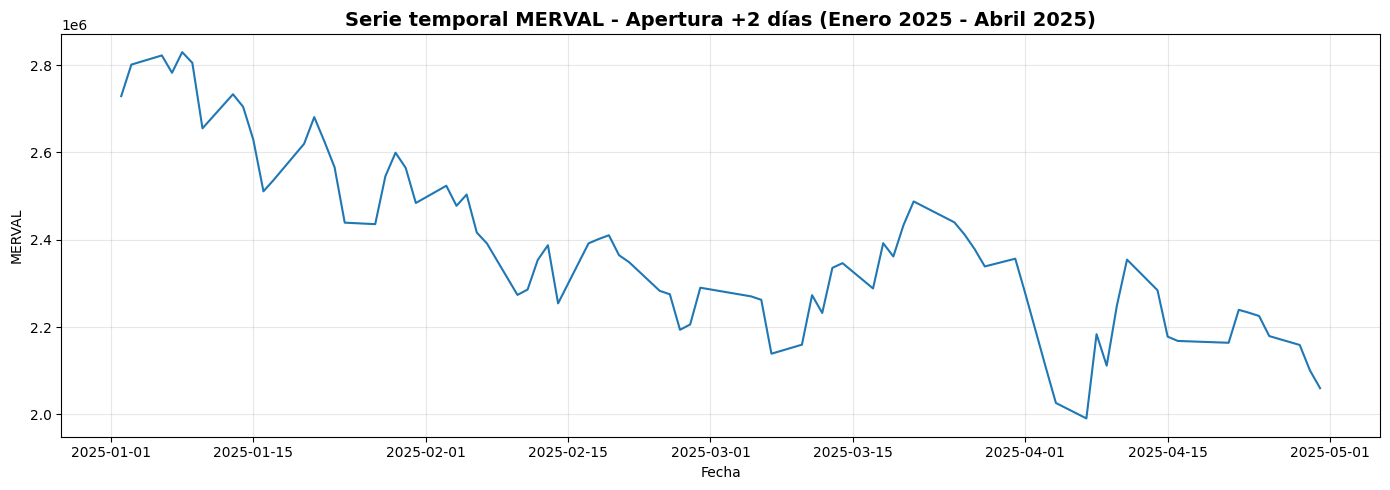

\nTest de estacionariedad (Augmented Dickey-Fuller)
ADF Statistic: -1.6926
p-value: 0.4349
Es estacionaria (p < 0.05): False
La serie NO es estacionaria, necesita diferenciación (d >= 1)


In [4]:
# Visualización de la serie temporal
plt.figure(figsize=(14, 5))
plt.plot(df.index.to_timestamp(), df['merval'])
plt.title('Serie temporal MERVAL - Apertura +2 días (Enero 2025 - Abril 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('MERVAL')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test de estacionariedad (Augmented Dickey-Fuller)
result = adfuller(df['merval'].dropna())
print('\\nTest de estacionariedad (Augmented Dickey-Fuller)')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Es estacionaria (p < 0.05): {result[1] < 0.05}')
if result[1] > 0.05:
    print('La serie NO es estacionaria, necesita diferenciación (d >= 1)')
else:
    print('La serie es estacionaria')

In [5]:
# Train-test split (80/20)
series = df["merval"]
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

print(f'Train: {train.index.min()} a {train.index.max()} ({len(train)} observaciones)')
print(f'Test:  {test.index.min()} a {test.index.max()} ({len(test)} observaciones)')

Train: 2025-01-02 a 2025-04-04 (63 observaciones)
Test:  2025-04-07 a 2025-04-30 (16 observaciones)


## 3. Búsqueda del Mejor Orden ARIMA (Grid Search)

In [6]:
# Probar diferentes combinaciones de (p, d, q)
import itertools

# Rangos reducidos para dataset pequeño (~85 observaciones)
p_values = range(0, 3)  # 0, 1, 2
d_values = range(0, 2)  # 0, 1
q_values = range(0, 3)  # 0, 1, 2

best_aic = np.inf
best_order = None

results = []

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model_temp = ARIMA(train, order=(p, d, q))
        fitted_temp = model_temp.fit()
        aic = fitted_temp.aic
        results.append({'order': (p, d, q), 'AIC': aic})
        
        if aic < best_aic:
            best_aic = aic
            best_order = (p, d, q)
    except:
        continue

print(f"Mejor modelo por AIC: ARIMA{best_order}")
print(f"AIC: {best_aic:.2f}")

# Mostrar top 5 modelos
results_df = pd.DataFrame(results).sort_values('AIC')
print("\nTop 5 modelos por AIC:")
print(results_df.head())

Mejor modelo por AIC: ARIMA(0, 1, 0)
AIC: 1564.09

Top 5 modelos por AIC:
        order          AIC
3   (0, 1, 0)  1564.094923
9   (1, 1, 0)  1565.045321
4   (0, 1, 1)  1565.130219
17  (2, 1, 2)  1565.269974
16  (2, 1, 1)  1566.982672


In [7]:
# Entrenar modelo ARIMA con el mejor orden encontrado
model = ARIMA(train, order=best_order)
res = model.fit()

# Mostrar resumen estadístico
print(res.summary())

# Predicción out-of-sample
forecast = res.forecast(steps=len(test))
forecast.index = test.index

# Calcular métricas de evaluación
rmse = root_mean_squared_error(test, forecast)
mae = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"\\nMétricas del modelo ARIMA{best_order}:")
print(f"  RMSE: {rmse:12,.2f}")
print(f"  MAE:  {mae:12,.2f}")
print(f"  MAPE: {mape:11.2f}%")

                               SARIMAX Results                                
Dep. Variable:                 merval   No. Observations:                   63
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -781.047
Date:                Sun, 16 Nov 2025   AIC                           1564.095
Time:                        11:51:28   BIC                           1566.222
Sample:                    01-02-2025   HQIC                          1564.930
                         - 04-04-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.042e+09   1.05e+09      4.818      0.000    2.99e+09    7.09e+09
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.93
Prob(Q):                              0.96   Pr

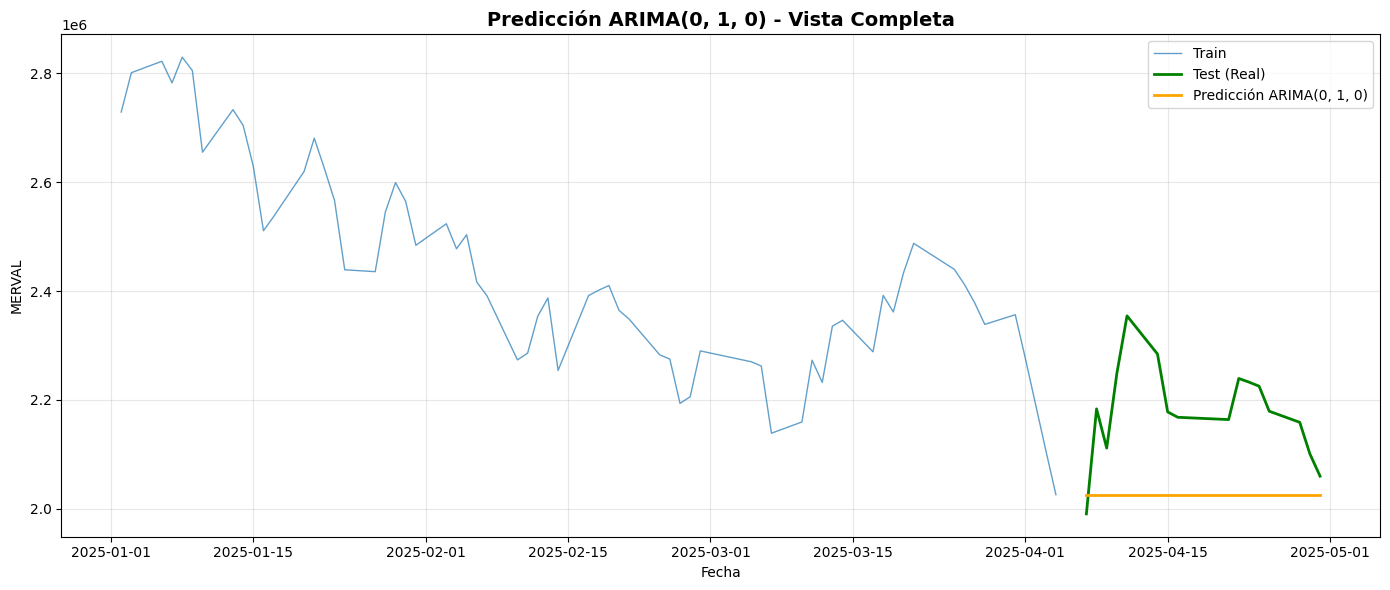

In [8]:
# Visualización completa: Train, Test y Predicción
plt.figure(figsize=(14, 6))
plt.plot(train.index.to_timestamp(), train, label="Train", alpha=0.7, linewidth=1)
plt.plot(test.index.to_timestamp(), test, label="Test (Real)", color='green', linewidth=2)
plt.plot(forecast.index.to_timestamp(), forecast, label=f"Predicción ARIMA{best_order}", color="orange", linewidth=2)
plt.title(f"Predicción ARIMA{best_order} - Vista Completa", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("MERVAL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

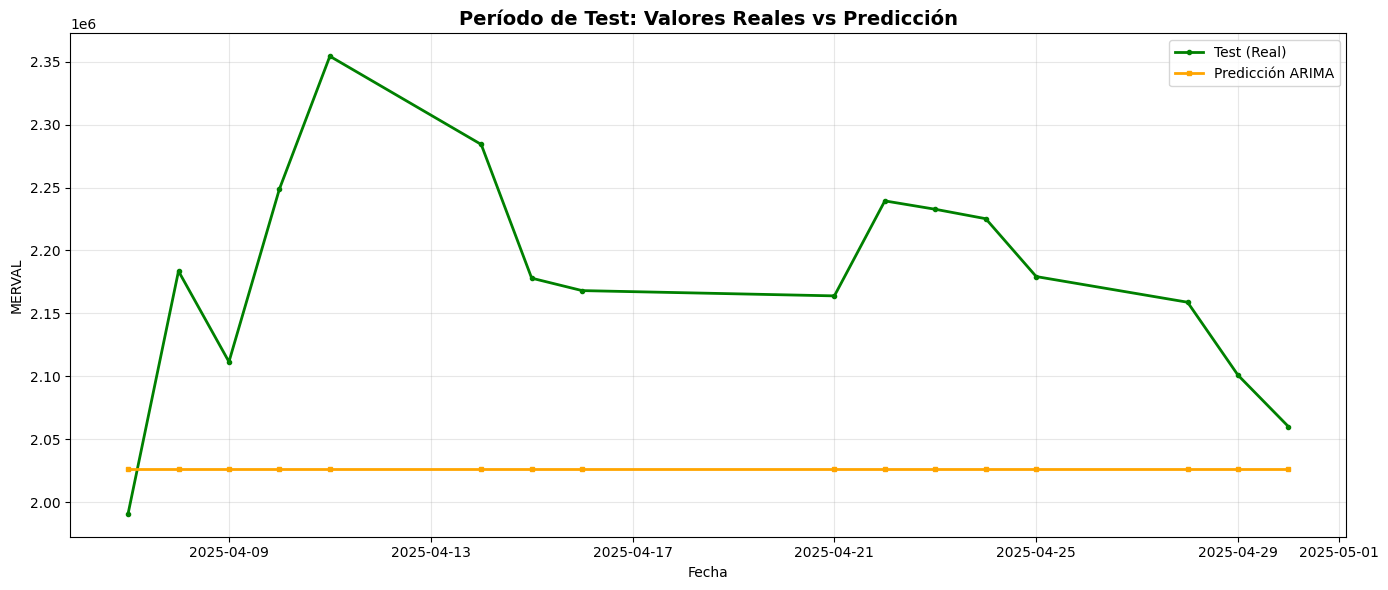

In [9]:
# Zoom en período de test
plt.figure(figsize=(14, 6))
plt.plot(test.index.to_timestamp(), test, label="Test (Real)", color='green', marker='o', markersize=3, linewidth=2)
plt.plot(forecast.index.to_timestamp(), forecast, label="Predicción ARIMA", color="orange", marker='s', markersize=3, linewidth=2)
plt.title("Período de Test: Valores Reales vs Predicción", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("MERVAL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Comparación con Modelos Alternativos

In [10]:
# Comparar con modelos más simples y baseline
models_to_test = [
    (0, 1, 1),  # Random walk con MA(1)
    (1, 1, 0),  # Random walk con AR(1)
    (1, 1, 1),  # ARIMA simple
    best_order,  # Modelo seleccionado por AIC
]

results_comparison = []

for order in models_to_test:
    try:
        model_temp = ARIMA(train, order=order)
        fitted_temp = model_temp.fit()
        
        fc_temp = fitted_temp.forecast(steps=len(test))
        fc_temp.index = test.index
        
        # Usar valores numpy
        test_values = test.values
        fc_values = fc_temp.values
        
        rmse_temp = root_mean_squared_error(test_values, fc_values)
        mae_temp = mean_absolute_error(test_values, fc_values)
        mape_temp = np.mean(np.abs((test_values - fc_values) / test_values)) * 100
        
        results_comparison.append({
            'Modelo': f'ARIMA{order}',
            'RMSE': float(rmse_temp),
            'MAE': float(mae_temp),
            'MAPE': float(mape_temp),
            'AIC': float(fitted_temp.aic)
        })
    except Exception as e:
        pass

# Modelo Naive
naive_fc = pd.Series([train.iloc[-1]] * len(test), index=test.index)
test_values = test.values
naive_values = naive_fc.values

rmse_naive = root_mean_squared_error(test_values, naive_values)
mae_naive = mean_absolute_error(test_values, naive_values)
mape_naive = np.mean(np.abs((test_values - naive_values) / test_values)) * 100

results_comparison.append({
    'Modelo': 'Naive',
    'RMSE': float(rmse_naive),
    'MAE': float(mae_naive),
    'MAPE': float(mape_naive),
    'AIC': None
})

# Mostrar resultados
df_comp = pd.DataFrame(results_comparison).sort_values('RMSE').reset_index(drop=True)

print("Resultados de comparación (ordenados por RMSE):\\n")
for idx, row in df_comp.iterrows():
    aic_str = f"{row['AIC']:,.0f}" if row['AIC'] is not None else "N/A"
    print(f"{idx+1}. {row['Modelo']:20s} | RMSE: {row['RMSE']:12,.2f} | MAE: {row['MAE']:12,.2f} | MAPE: {row['MAPE']:6.2f}% | AIC: {aic_str}")

best_model = df_comp.iloc[0]
print(f"\\nMejor modelo: {best_model['Modelo']}")
print(f"  RMSE: {best_model['RMSE']:,.2f}")
print(f"  MAE:  {best_model['MAE']:,.2f}")
print(f"  MAPE: {best_model['MAPE']:.2f}%")

Resultados de comparación (ordenados por RMSE):\n
1. ARIMA(0, 1, 0)       | RMSE:   176,055.38 | MAE:   158,413.77 | MAPE:   7.14% | AIC: 1,564
2. Naive                | RMSE:   176,055.38 | MAE:   158,413.77 | MAPE:   7.14% | AIC: nan
3. ARIMA(0, 1, 1)       | RMSE:   177,824.06 | MAE:   160,180.37 | MAPE:   7.22% | AIC: 1,565
4. ARIMA(1, 1, 0)       | RMSE:   177,987.54 | MAE:   160,346.31 | MAPE:   7.23% | AIC: 1,565
5. ARIMA(1, 1, 1)       | RMSE:   178,318.02 | MAE:   160,682.79 | MAPE:   7.24% | AIC: 1,567
\nMejor modelo: ARIMA(0, 1, 0)
  RMSE: 176,055.38
  MAE:  158,413.77
  MAPE: 7.14%


## 5. Conclusiones y Hallazgos

### Resultado Principal

El mejor modelo seleccionado por AIC es **ARIMA(0,1,0)**, que es matemáticamente equivalente al modelo **Naive (Random Walk)**:
- Ambos tienen **exactamente las mismas métricas**:
  - RMSE: 176,055.38
  - MAE: 158,413.77
  - MAPE: 7.14%

### Análisis de Resultados

#### ARIMA(0,1,0) es el modelo óptimo
- Con un dataset reducido (63 observaciones de entrenamiento), el criterio AIC correctamente selecciona el modelo más parsimonioso
- ARIMA(0,1,0) representa un **Random Walk puro**: Y_t = Y_{t-1} + ε_t
- Esto significa que la mejor predicción del valor futuro es simplemente el último valor observado

#### Modelos más complejos empeoran la predicción
- ARIMA(0,1,1): RMSE aumenta a 177,824 (+1.0%)
- ARIMA(1,1,0): RMSE aumenta a 177,987 (+1.1%)
- ARIMA(1,1,1): RMSE aumenta a 178,318 (+1.3%)

Los componentes AR y MA adicionales **sobreajustan** con tan pocos datos y empeoran la generalización.

#### El dataset reducido favorece la simplicidad
Con solo 63 observaciones para entrenamiento:
- No hay datos suficientes para estimar modelos complejos de forma confiable
- El modelo más simple (Random Walk) es el más robusto
- Los rangos reducidos (p,q ∈ {0,1,2}) fueron apropiados - modelos más complejos no tienen sentido

### Implicaciones para Series Financieras de Corto Plazo

#### Por qué ARIMA(0,1,0) es el mejor modelo

1. **Eficiencia del mercado**: En períodos cortos (4 meses), los precios del MERVAL siguen un Random Walk - los movimientos futuros no son predecibles a partir de patrones históricos
2. **Alta persistencia**: La serie tiene fuerte autocorrelación en lag 1, pero no hay patrones AR/MA explotables más allá de esto
3. **Datos limitados**: Con 63 observaciones, no hay información suficiente para detectar patrones más complejos (si existieran)

#### Limitaciones del horizonte de predicción

- El test predice **16 pasos adelante** (días de trading)
- Para un Random Walk, la incertidumbre crece linealmente con el horizonte
- MAPE del 7.14% refleja la dificultad de predecir el MERVAL a medio plazo

### Conclusión Final

Para este dataset reducido (Enero-Abril 2025), **ARIMA no ofrece ventaja sobre el modelo Naive**. El criterio AIC correctamente identifica que ARIMA(0,1,0) - equivalente a predecir el último valor observado - es la estrategia óptima.

Esto indica que:
- La serie del MERVAL en este período se comporta como un **Random Walk puro**
- Los movimientos futuros no son predecibles mediante patrones históricos ARIMA
- Cualquier estrategia de predicción más sofisticada requerirá:
  - Variables exógenas (features adicionales)
  - Modelos no lineales (ML/DL)
  - O más datos históricos para detectar patrones estacionales de largo plazo

**Recomendación**: Considerar modelos multivariados (ARIMAX, VAR) o modelos de Machine Learning que incorporen las 60+ features disponibles en el dataset, ya que ARIMA univariado no captura información predictiva útil más allá de la persistencia temporal.